# 1. Setup
## 1.1 Config + Logger import

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# ====== Imports ======
# Config
from config_loader import CONFIG

# Logger: LoggerManager + global configuration
from loggerplusplus import LoggerManager, LogLevels, LoggerConfig, Logger, logger_colors

LoggerManager.enable_files_logs_monitoring_only_for_one_logger = (
    CONFIG.LOGGER_MANAGER_ENABLE_FILES_LOGS_MONITORING_ONLY_FOR_ONE_LOGGER
)
LoggerManager.enable_dynamic_config_update = CONFIG.LOGGER_MANAGER_ENABLE_DYNAMIC_CONFIG_UPDATE
LoggerManager.enable_unique_logger_identifier = CONFIG.LOGGER_MANAGER_ENABLE_UNIQUE_LOGGER_IDENTIFIER

LoggerManager.global_config = LoggerConfig.from_kwargs(
    colors=getattr(logger_colors, CONFIG.LOGGER_COLORS),
    path=CONFIG.LOGGER_PATH,
    # LogLevels
    decorator_log_level=getattr(LogLevels, CONFIG.LOGGER_DECORATOR_LOG_LEVEL),
    print_log_level=getattr(LogLevels, CONFIG.LOGGER_PRINT_LOG_LEVEL),
    file_log_level=getattr(LogLevels, CONFIG.LOGGER_FILE_LOG_LEVEL),
    # Loggers Output
    print_log=CONFIG.LOGGER_PRINT_LOG,
    write_to_file=CONFIG.LOGGER_WRITE_TO_FILE,
    # Monitoring
    display_monitoring=CONFIG.LOGGER_DISPLAY_MONITORING,
    files_monitoring=CONFIG.LOGGER_FILES_MONITORING,
    file_size_unit=CONFIG.LOGGER_FILE_SIZE_UNIT,
    disk_alert_threshold_percent=CONFIG.LOGGER_DISK_ALERT_THRESHOLD_PERCENT,
    log_files_size_alert_threshold_percent=CONFIG.LOGGER_FILES_SIZE_ALERT_THRESHOLD_PERCENT,
    max_log_file_size=CONFIG.LOGGER_MAX_LOG_FILE_SIZE,
    # Placement
    identifier_max_width=CONFIG.LOGGER_IDENTIFIER_MAX_WIDTH,
    filename_lineno_max_width=CONFIG.LOGGER_FILENAME_LINENO_MAX_WIDTH,
)

## 1.2 Importing Libraries

In [3]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import time

from arena import ShowArena, TeamColor, GridManager
from geometry import OrientedPoint
from movement import GoToParams, MovementManager, TrajectoryParams, SpeedProfile

# 2 Serialization tests

In [4]:
logger = Logger(identifier="SerTester", print_log_level=LogLevels.DEBUG, write_to_file=False, level_max_width=8, filename_lineno_max_width=5, colors=logger_colors.DarkModeColors)

def compare_attributes(obj1, obj2, prefix='', indent=0, logger=logger):
    """
    Recursively compares attributes of two objects and logs the result of each comparison.
    It returns a list of difference messages if any differences are found.

    Args:
        obj1: The original object (or sub-object).
        obj2: The deserialized object (or sub-object).
        prefix: A string representing the current attribute path.
        indent: Current indentation level for log messages.
        logger: The logger to use for logging.

    Returns:
        A list of strings describing the differences.
    """
    differences = []
    indent_str = "    " * indent  # 4 spaces per indent level
    current_path = prefix if prefix else "root"
    logger.info(f"{indent_str}Comparing {current_path}: {obj1} vs {obj2}")

    # If both objects are dictionaries, compare key by key.
    if isinstance(obj1, dict) and isinstance(obj2, dict):
        all_keys = set(obj1.keys()) | set(obj2.keys())
        for key in all_keys:
            val1 = obj1.get(key, None)
            val2 = obj2.get(key, None)
            new_prefix = f"{prefix}{key}"
            if val1 == val2:
                logger.info(f"{indent_str}    Key '{key}' equal: {val1} == {val2}")
            else:
                logger.warning(f"{indent_str}    Key '{key}' differs: {val1} != {val2}")
                differences.extend(compare_attributes(val1, val2, prefix=new_prefix + ".", indent=indent+1, logger=logger))
                
    # If both objects are lists or tuples, compare element by element.
    elif isinstance(obj1, (list, tuple)) and isinstance(obj2, (list, tuple)):
        if len(obj1) != len(obj2):
            diff_msg = f"{prefix} length differs: {len(obj1)} != {len(obj2)}"
            logger.warning(f"{indent_str}{diff_msg}")
            differences.append(diff_msg)
        else:
            logger.info(f"{indent_str}Both lists/tuples have the same length: {len(obj1)}")
        for index, (item1, item2) in enumerate(zip(obj1, obj2)):
            new_prefix = f"{prefix}[{index}]"
            if item1 == item2:
                logger.info(f"{indent_str}    Index [{index}] equal: {item1} == {item2}")
            else:
                logger.warning(f"{indent_str}    Index [{index}] differs: {item1} != {item2}")
                differences.extend(compare_attributes(item1, item2, prefix=new_prefix + ".", indent=indent+1, logger=logger))
                
    # If both objects have __dict__, compare their attributes.
    elif hasattr(obj1, '__dict__') and hasattr(obj2, '__dict__'):
        dict1 = vars(obj1)
        dict2 = vars(obj2)
        all_keys = set(dict1.keys()) | set(dict2.keys())
        for key in all_keys:
            val1 = dict1.get(key, None)
            val2 = dict2.get(key, None)
            new_prefix = f"{prefix}{key}"
            if val1 == val2:
                logger.info(f"{indent_str}    Attribute '{key}' equal: {val1} == {val2}")
            else:
                logger.warning(f"{indent_str}    Attribute '{key}' differs: {val1} != {val2}")
                differences.extend(compare_attributes(val1, val2, prefix=new_prefix + ".", indent=indent+1, logger=logger))
                
    else:
        # Fallback: Directly compare the two objects.
        if obj1 != obj2:
            diff_msg = f"{prefix[:-1]}: original = {obj1}, deserialized = {obj2}"
            logger.warning(f"{indent_str}{diff_msg}")
            differences.append(diff_msg)
        else:
            logger.info(f"{indent_str}{current_path} are equal: {obj1} == {obj2}")
            
    return differences

def test_serialization(obj, logger=logger) -> bool:
    """
    Tests the serialization and deserialization of an object using pickle.
    If the test fails (i.e., the objects differ), performs a detailed attribute-by-attribute
    analysis to show where the differences occur, with logs.

    Args:
        obj: The object to test.
        logger: The logger to use for logging.

    Returns:
        bool: True if the object is identical after deserialization, False otherwise.
    """
    logger.info("Starting serialization test...")
    try:
        serialized_obj = pickle.dumps(obj)
        logger.info("Serialization successful.")
    except Exception as e:
        logger.error(f"Error during serialization: {e}")
        return False

    try:
        deserialized_obj = pickle.loads(serialized_obj)
        logger.info("Deserialization successful.")
    except Exception as e:
        logger.error(f"Error during deserialization: {e}")
        return False

    try:
        if obj == deserialized_obj:
            logger.info("Test passed: object is identical after deserialization.")
            return True
        else:
            logger.warning("Test failed: object differs after deserialization.")
            logger.info("Starting attribute-by-attribute comparison...")
            differences = compare_attributes(obj, deserialized_obj, logger=logger)
            if differences:
                logger.warning("Differences found:")
                for diff in differences:
                    logger.warning(diff)
            else:
                logger.info("No attribute differences could be determined.")
            return False
    except Exception as e:
        logger.error(f"Error during comparison: {e}")
        return False


14:09:15.964992 -> [ SerTester ] [..:175]   INFO   | === Logs Cleaning Info ===
14:09:16.221607 -> [ SerTester ] [..:185]   INFO   | Log size within limits (0.06Go/1.0Go).


## 2.1 Test 1: Serialization of GridManager

In [5]:
grid_manager = GridManager(
    logger=Logger(identifier="GridManager", follow_manager_rules=True),
    chunk_size=50,
    width=300,
    height=200,
    forbidden_cover_threshold=CONFIG.ARENA_FORBIDDEN_COVER_THRESHOLD
)
test_serialization(grid_manager)

14:09:16.250541 -> [ SerTester ] [1..:91]   INFO   | Starting serialization test...
14:09:16.252540 -> [ SerTester ] [1..:94]   INFO   | Serialization successful.
14:09:16.253790 -> [ SerTester ] [..:101]   INFO   | Deserialization successful.
14:09:16.254798 -> [ SerTester ] [..:108]   INFO   | Test passed: object is identical after deserialization.


True

Check the Grid behavior after serialization

In [6]:
grid_manager.static_grid.nodes[0][0].walkable = False
serialized_obj = pickle.dumps(grid_manager)
deserialized_obj = pickle.loads(serialized_obj)

In [7]:
for row in grid_manager.static_grid.nodes:
    for node in row:
        if node.walkable:
            print(".", end="")
        else:
            print("X", end="")
    print()

X.....
......
......
......


## 2.2 Test 2: Serialization of Arena

In [8]:
arena = ShowArena(
    logger=Logger(identifier="ShowArena", follow_manager_rules=True),
    border_buffer=CONFIG.ARENA_BORDER_BUFFER,
    obstacle_buffer=CONFIG.ARENA_OBSTACLE_BUFFER,
    chunk_size=CONFIG.ARENA_CHUNK_SIZE,
    forbidden_cover_threshold=CONFIG.ARENA_FORBIDDEN_COVER_THRESHOLD,
    grid_manager_logger=Logger(identifier="GridManager", follow_manager_rules=True),
)
test_serialization(arena)

14:09:18.492816 -> [ ShowArena ] [  arena.py  :219]    INFO    | ShowArena initialized.
14:09:18.493805 -> [ ShowArena ] [  arena.py  :220]   DEBUG    | Width: 300, Height: 200
14:09:18.494806 -> [ SerTester ] [1..:91]   INFO   | Starting serialization test...
14:09:18.503828 -> [ SerTester ] [1..:94]   INFO   | Serialization successful.
14:09:18.513807 -> [ SerTester ] [..:101]   INFO   | Deserialization successful.
14:09:18.518806 -> [ SerTester ] [..:108]   INFO   | Test passed: object is identical after deserialization.


True

In [9]:
serialized_obj = pickle.dumps(arena)
deserialized_obj = pickle.loads(serialized_obj)

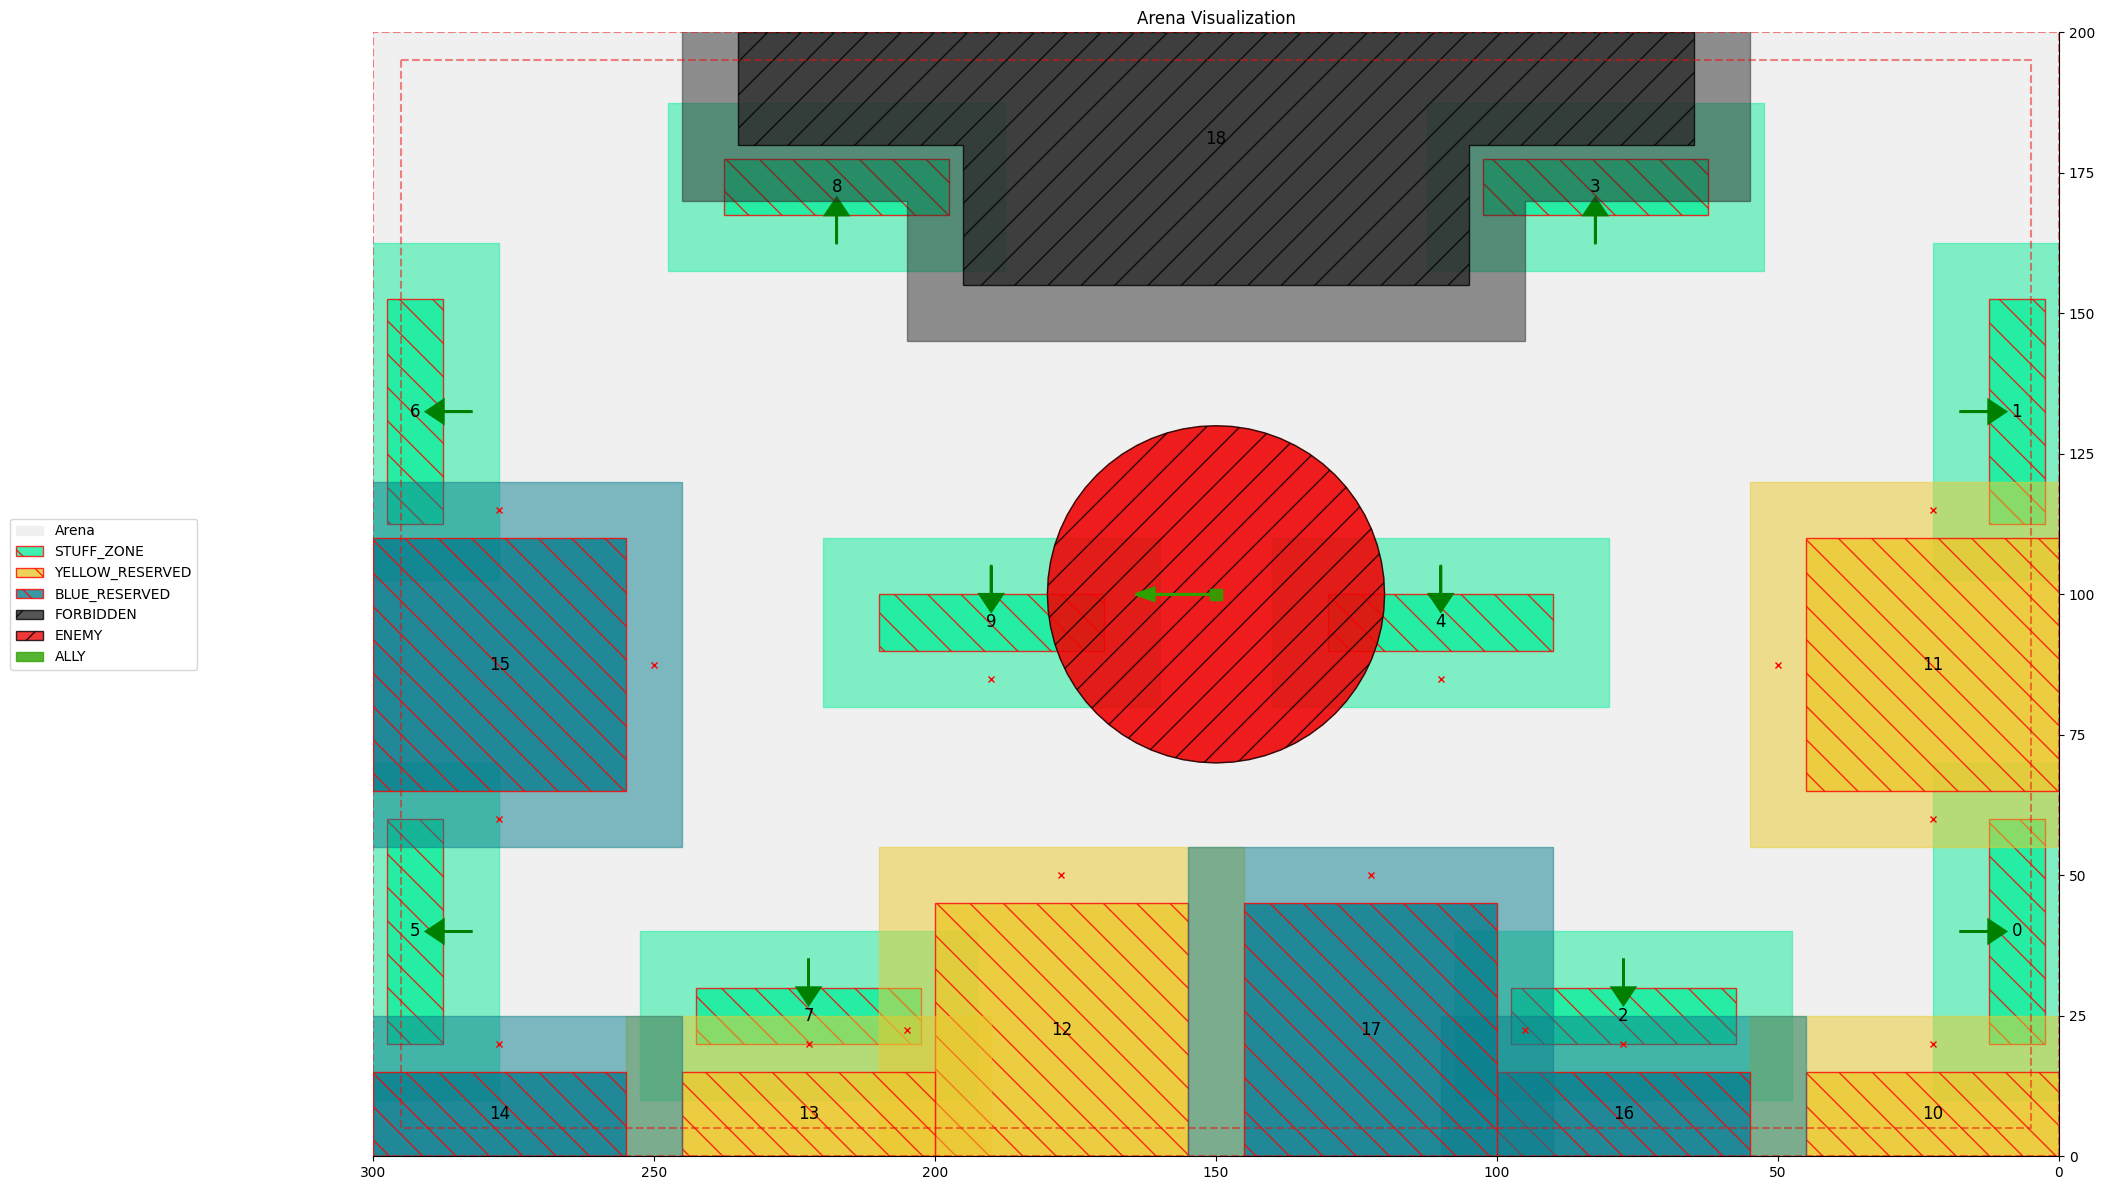

(<Axes: title={'center': 'Arena Visualization'}>,
 <Figure size 2000x1200 with 1 Axes>)

In [10]:
arena.visualize()

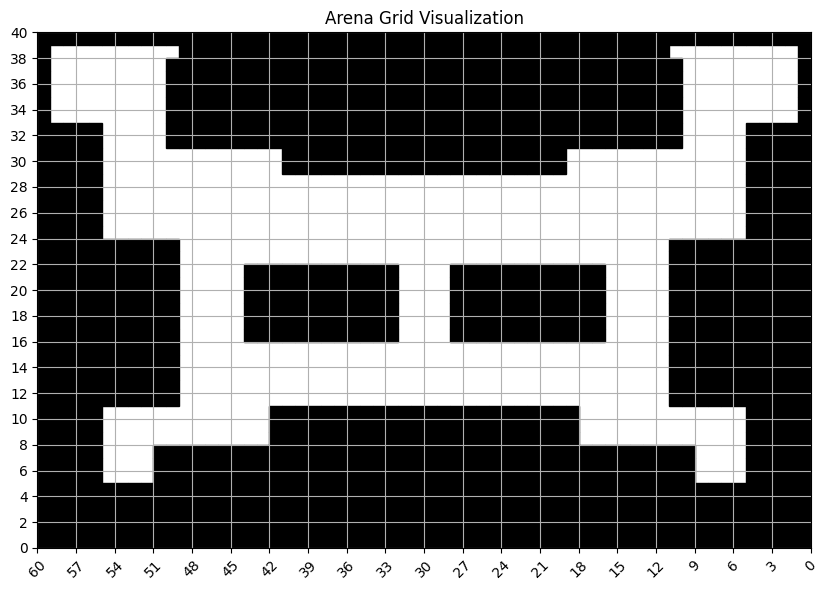

(<Axes: title={'center': 'Arena Grid Visualization'}>,
 <Figure size 1200x600 with 1 Axes>)

In [11]:
arena.grid_manager.visualize()